In [12]:
import numpy as np
import scipy.signal
import scipy.linalg
import cvxpy as cp
import matplotlib.pyplot as plt

In [13]:
m_B = 51.66 # mass of robot body (kg)
m_b = 2.44 # mass of ball (kg)
l = 0.69 # distance from ball COM to total COM (m)
I_b = 0.0174 # ball moment of inertia (kg-m^2)
r_b = 0.1058 # ball radius (m)
I_B = 12.59 # intertia of body wrt center of ball (kg-m^2)
mu_theta = 3.68 # theta viscous damping coefficient (N-m-s/rad)
mu_phi = 3.68 # phi viscous damping coefficient (N-m-s/rad)
dt = 0.1
g = 9.81
ki = 0.05
kp = 10

Gamma_1 = I_b + I_B + m_b * r_b**2 + m_B * r_b**2 + m_B * l**2
Gamma_2 = I_B + m_B * l**2

# Define the mass matrix M_*
M_star = np.array([
    [Gamma_1 + 2 * m_B * l, Gamma_2 + m_B * l],
    [Gamma_2 + m_B * l, Gamma_2]
])

# Compute the inverse of the mass matrix
M_star_inv = np.linalg.inv(M_star)

# Define the matrix to be multiplied by M_star_inv
matrix_to_multiply = np.array([
    [-m_B * g * l, -m_B * g * l, mu_theta, 0, 0],
    [-m_B * g * l -ki, -m_B * g * l ,- kp, mu_phi, ki]
])

# Compute the resulting matrix
result_matrix = np.dot(M_star_inv, matrix_to_multiply)
result_matrix_2 = np.dot(M_star_inv, np.array([0, kp]))

# Construct the final A matrix
A = np.array([
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [result_matrix[0, 0], result_matrix[0, 1], result_matrix[0, 2], result_matrix[0, 3], result_matrix[0, 4]],
    [result_matrix[1, 0], result_matrix[1, 1], result_matrix[1, 2], result_matrix[1, 3], result_matrix[1, 4]],
    [0, 0, 0, 0, 0]
])

# Define the B matrix
B = np.array([
    [0],
    [0],
    [result_matrix_2[0]],
    [result_matrix_2[1]],
    [1]
])

sys_cont = scipy.signal.StateSpace(A, B, np.eye(5), np.zeros((5, 1)))
sys_disc = sys_cont.to_discrete(dt)
A_d = sys_disc.A
B_d = sys_disc.B


In [14]:
T = 700  # time steps
n = 5   # state dimension
m = 1   # control dimension
MPC = 20 # MPC time horizon

Q = np.diag([100, 100, 1, 1, 0])
R = np.array([[1]])

Initial_tilt = 0 # insert in degrees
IT_R = Initial_tilt * np.pi/180 # conversion to rad

Initial_velocity = 0 # insert in deg/s
IV_R = Initial_velocity * np.pi/180 #convert to rad/s

Initial_displacement = 1 # insert in m
ID_R = Initial_displacement / r_b # convert to rad

limit = 5 * np.pi/180 # angle limit
speed_limit = 0.04 / r_b

#initial_state = np.array([ID_R, IT_R, 0.0, IV_R, 0]) #Just angle displacement
initial_state = np.array([ID_R, -ID_R - IT_R, 0.0, IV_R, 0]) #Just ball displacement
state = initial_state
goal_state = np.zeros(5)

# initializing states
states = np.zeros((T+1, n))
controls = np.zeros((T, m))
states[0] = state


# MPC Loop
for k in range(T):

    # cvxpy optimization variables
    xs = cp.Variable((MPC+1, n))
    us = cp.Variable((MPC, m))

    objective = 0
    constraints = [xs[0] == state]

    for t in range(MPC):
        objective += (cp.quad_form(xs[t], Q) + cp.quad_form(us[t],R))
        constraints += [xs[t+1] == A_d @ xs[t] + B_d @ us[t]]
        #constraints += [xs[t, 1] + xs[t,0] <= limit, xs[t, 1] + xs[t,0] >= -limit]
        constraints += [xs[t, 2] <= speed_limit, xs[t, 2] >= -speed_limit] # speed limit
    
    objective += cp.quad_form(xs[MPC] - goal_state, Q)

    # solving optimization problem
    problem = cp.Problem(cp.Minimize(objective), constraints)
    problem.solve()

    # applying first control input
    u = us.value[0]
    controls[k] = u

    # calculating next state 
    state = A_d @ state + B_d @ u 
    states[k+1] = state


linear_position = states[:,0] * r_b

states = states * 180 / np.pi

test = np.sin(states[:,0] + states[:,1])
test2 = states[:,1] + states [:,0]

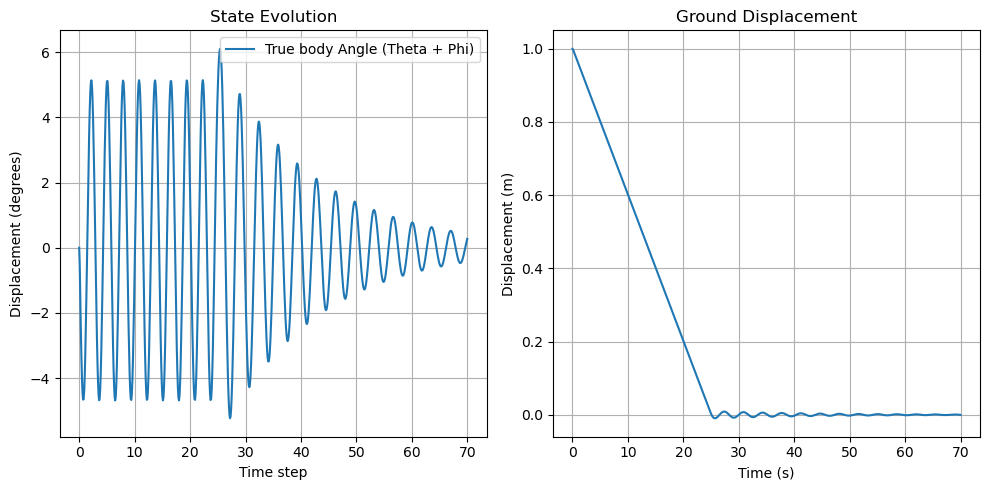

In [15]:
Time = np.arange(0, T*dt + dt, dt)

# Plot the states
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
#plt.plot(Time, test, label = 'Sin(Theta + Phi)')
plt.plot(Time, -test2, label = 'True body Angle (Theta + Phi)')
#plt.plot(Time, states[:, 0], label='Ball Displacement')
#plt.plot(Time, states[:, 1], label='Body Angle')
#plt.plot(states[:, 2], label='Theta_D')
#plt.plot(states[:, 3], label='Phi_D')
plt.xlabel('Time step')
plt.ylabel('Displacement (degrees)')
plt.legend()
plt.title('State Evolution')
plt.grid()

# Plot the control input
plt.subplot(1, 2, 2)
plt.plot(Time, linear_position)
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Ground Displacement')
plt.grid()

plt.tight_layout()
plt.show()